# Stage 01 — Dataset exploration

| | |
|---|---|
| **Intention** | Peek at raw Uzbek→gloss annotations before training, incl. length/vocab/growth charts. |
| **Input** | newest file in `data/raw/*.jsonl` (auto-detected) |
| **Output** | inline plots only (read-only, no files written) |
| **Runtime** | seconds |


In [4]:
import sys
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT / "src"))

from ttg.config import DATA_DIR, CHECKPOINTS_DIR, ARTIFACTS, PROJECT_ROOT
print("PROJECT_ROOT =", PROJECT_ROOT)
print("DATA_DIR     =", DATA_DIR)
print("CHECKPOINTS  =", CHECKPOINTS_DIR)


PROJECT_ROOT = /home/khurshida/Projects/uzsl-text-to-gloss
DATA_DIR     = /home/khurshida/Projects/uzsl-text-to-gloss/data
CHECKPOINTS  = /home/khurshida/Projects/uzsl-text-to-gloss/artifacts/ckpts


In [5]:
from ttg.data import latest_raw_dataset, load_raw

raw_path = latest_raw_dataset()
print("raw_path:", raw_path)
rows = load_raw(raw_path)
print(f"rows: {len(rows)}")
print("keys:", sorted(rows[0].keys()))
print()
for r in rows[:3]:
    print("TEXT :", r["text"])
    print("GLOSS:", r["gloss"])
    print("---")

gloss_lens = [len(str(r["gloss"]).split()) for r in rows]
text_lens = [len(str(r["text"]).split()) for r in rows]
print(f"avg text tokens : {sum(text_lens)/len(text_lens):.1f}")
print(f"avg gloss tokens: {sum(gloss_lens)/len(gloss_lens):.1f}")


raw_path: /home/khurshida/Projects/uzsl-text-to-gloss/data/raw/sentences_correct_1408.jsonl
rows: 1408
keys: ['created_at', 'gloss', 'gloss_completed', 'public_id', 'text', 'updated_at']

TEXT : Davlat rahbarlari keyingi yillarda ko'p qirrali hamkorlik jadal rivojlanib borayotganini katta mamnuniyat bilan qayd etdi.
GLOSS: davlat boshliq keyingi yil ko'p har xil do'stlashmoq tez rivojlanmoq juda xursand bo'ldi
---
TEXT : Svetoforning qizil chirog'i ham yoniq edi.
GLOSS: svetofor qizil rang ham yonmoq bo'ldi
---
TEXT : Noyabrda velosipedchi Nikolay Sderjikovni Eski Toshmi yaqinida elektromobil urib yubordi.
GLOSS: noyabr oy velosiped boshqarmoq nikolay sderjikov eski tibbiyot institut yonida elektromobil avariya bo'ldi
---
avg text tokens : 10.1
avg gloss tokens: 10.0


## Length distributions

Training notebooks truncate at `MAX_SOURCE=128` (text) / `MAX_TARGET=64`
(gloss) tokens (see `notebooks/03`–`06`). Check how much of the corpus
would actually be clipped at those limits.


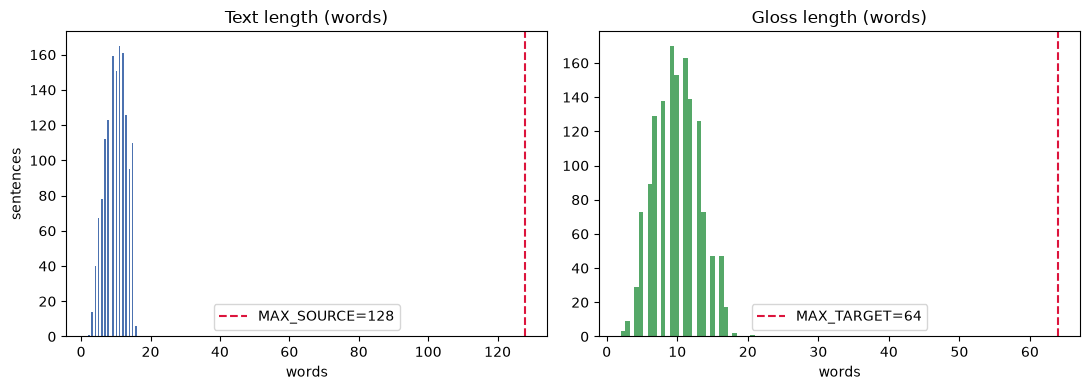

text  > MAX_SOURCE: 0.0%
gloss > MAX_TARGET: 0.0%


In [6]:
%matplotlib inline
import matplotlib.pyplot as plt

MAX_SOURCE = 128
MAX_TARGET = 64

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(text_lens, bins=30, color="#4C72B0")
axes[0].axvline(MAX_SOURCE, color="crimson", linestyle="--", label=f"MAX_SOURCE={MAX_SOURCE}")
axes[0].set_title("Text length (words)")
axes[0].set_xlabel("words")
axes[0].set_ylabel("sentences")
axes[0].legend()

axes[1].hist(gloss_lens, bins=30, color="#55A868")
axes[1].axvline(MAX_TARGET, color="crimson", linestyle="--", label=f"MAX_TARGET={MAX_TARGET}")
axes[1].set_title("Gloss length (words)")
axes[1].set_xlabel("words")
axes[1].legend()

fig.tight_layout()
plt.show()

over_source = sum(1 for n in text_lens if n > MAX_SOURCE) / len(text_lens)
over_target = sum(1 for n in gloss_lens if n > MAX_TARGET) / len(gloss_lens)
print(f"text  > MAX_SOURCE: {over_source:.1%}")
print(f"gloss > MAX_TARGET: {over_target:.1%}")


## Text length vs. gloss length

Gloss sequences are usually shorter than the source sentence (function
words / morphology get dropped). This scatter shows the relationship
and the average compression ratio.


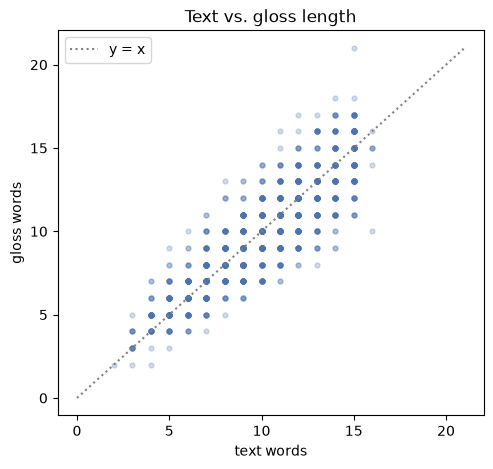

mean gloss/text ratio: 1.00  (corr=0.88)


In [7]:
import numpy as np

fig, ax = plt.subplots(figsize=(5.5, 5))
ax.scatter(text_lens, gloss_lens, alpha=0.25, s=12, color="#4C72B0")
lim = max(max(text_lens), max(gloss_lens))
ax.plot([0, lim], [0, lim], color="grey", linestyle=":", label="y = x")
ax.set_xlabel("text words")
ax.set_ylabel("gloss words")
ax.set_title("Text vs. gloss length")
ax.legend()
plt.show()

ratio = np.array(gloss_lens) / np.array(text_lens)
corr = np.corrcoef(text_lens, gloss_lens)[0, 1]
print(f"mean gloss/text ratio: {ratio.mean():.2f}  (corr={corr:.2f})")


## Gloss vocabulary

Sign gloss vocabularies are typically much smaller/more repetitive than
free text — worth confirming, since it affects how much LoRA/seq2seq
training data is actually needed per gloss token.


gloss vocab: 2330 unique / 14039 total tokens
text  vocab: 5645 unique / 14177 total tokens


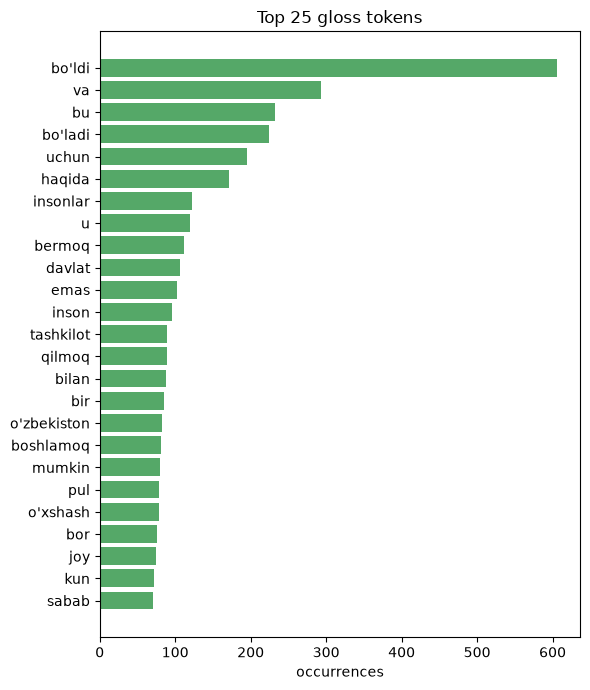

In [8]:
from collections import Counter

gloss_tokens = [tok for r in rows for tok in str(r["gloss"]).lower().split()]
text_tokens = [tok for r in rows for tok in str(r["text"]).lower().split()]
gloss_vocab = Counter(gloss_tokens)
text_vocab = Counter(text_tokens)
print(f"gloss vocab: {len(gloss_vocab)} unique / {len(gloss_tokens)} total tokens")
print(f"text  vocab: {len(text_vocab)} unique / {len(text_tokens)} total tokens")

top_n = gloss_vocab.most_common(25)
labels, counts = zip(*top_n)
fig, ax = plt.subplots(figsize=(6, 7))
ax.barh(range(len(labels)), counts, color="#55A868")
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels)
ax.invert_yaxis()
ax.set_xlabel("occurrences")
ax.set_title("Top 25 gloss tokens")
fig.tight_layout()
plt.show()


## Dataset growth over time

Cumulative annotated sentences by `created_at` date — sanity check for
how the corpus has grown across annotation batches/uploads.


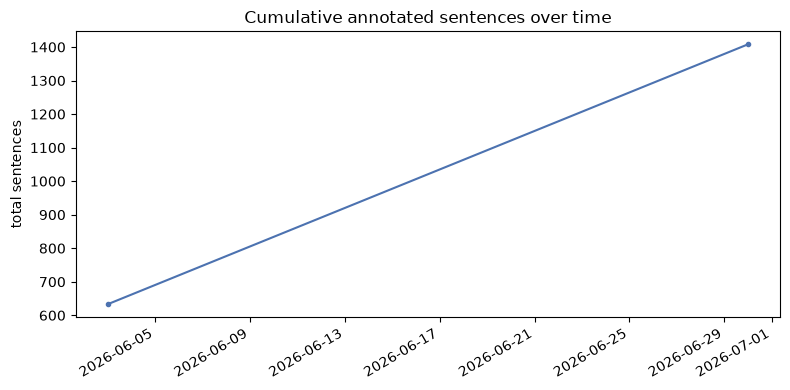

span: 2026-06-03 .. 2026-06-30 (2 days with new annotations)


In [9]:
from datetime import datetime

dated = [r["created_at"] for r in rows if r.get("created_at")]
days = sorted(datetime.fromisoformat(d).date() for d in dated)
day_counts = Counter(days)
unique_days = sorted(day_counts)
cumulative = np.cumsum([day_counts[d] for d in unique_days])

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(unique_days, cumulative, marker="o", markersize=3, color="#4C72B0")
ax.set_title("Cumulative annotated sentences over time")
ax.set_ylabel("total sentences")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

print(f"span: {unique_days[0]} .. {unique_days[-1]} ({len(unique_days)} days with new annotations)")
